# Laboratorio 5 – Naive Bayes

**Continuación directa del Lab 4** — se reutilizan el mismo dataset preprocesado,
el mismo `train_test_split(random_state=42)` y la misma variable categórica `price_category`.


## Configuración
Reutilizar todo el pipeline del Lab 4

In [6]:
import pyreadr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                              accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import KMeans

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110
print("Librerías cargadas.")


Librerías cargadas.


In [7]:
# PASO 1: Cargar datos
result = pyreadr.read_r('listings.Rdata')
df_raw = result[list(result.keys())[0]].copy()

# PASO 2: Limpiar precio (FIX)
df = df_raw.copy()

df['price'] = (
    df['price']
    .astype(str)
    .str.replace(r'[\$,]', '', regex=True)
    .str.strip()
)

# Convertir a numérico (manejo robusto)
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# Eliminar valores inválidos
df = df.dropna(subset=['price'])

# Filtrar outliers
q_high = df['price'].quantile(0.99)
df = df[(df['price'] > 0) & (df['price'] <= q_high)].copy()

# PASO 3: Eliminar columnas irrelevantes
cols_to_drop = ['id','listing_url','scrape_id','last_scraped','source','name',
    'description','neighborhood_overview','picture_url','host_url',
    'host_thumbnail_url','host_picture_url','host_about','host_verifications',
    'amenities','calendar_updated','calendar_last_scraped','license',
    'bathrooms_text','minimum_minimum_nights','maximum_minimum_nights',
    'minimum_maximum_nights','maximum_maximum_nights',
    'minimum_nights_avg_ntm','maximum_nights_avg_ntm']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
null_pct = df.isnull().mean()
df = df.drop(columns=null_pct[null_pct > 0.60].index.tolist())

# PASO 4: Ingeniería de fechas
if 'host_since' in df.columns:
    df['host_since'] = pd.to_datetime(df['host_since'], errors='coerce')
    df['host_years'] = ((pd.Timestamp('2024-01-01') - df['host_since']).dt.days / 365).round(1)
    df = df.drop(columns=['host_since'])
df = df.drop(columns=[c for c in ['first_review','last_review'] if c in df.columns], errors='ignore')

# PASO 5: Booleanos y tasas
for col in ['host_is_superhost','host_has_profile_pic','host_identity_verified',
            'has_availability','instant_bookable']:
    if col in df.columns:
        df[col] = df[col].map({'t':1,'f':0,True:1,False:0})

for col in ['host_response_rate','host_acceptance_rate']:
    if col in df.columns:
        df[col] = pd.to_numeric(
            df[col].str.replace('%','',regex=False).str.strip(),
            errors='coerce'
        )

# PASO 6: Selección y OHE
TARGET = 'price'
num_features = [c for c in df.select_dtypes(include='number').columns if c != TARGET]
cat_features = [c for c in ['room_type','property_type','neighbourhood_cleansed',
                              'host_response_time'] if c in df.columns]

for col in cat_features:
    freq = df[col].value_counts(normalize=True)
    df[col] = df[col].replace(freq[freq < 0.01].index, 'Otro')

df_encoded = pd.get_dummies(
    df[num_features + cat_features + [TARGET]],
    columns=cat_features,
    drop_first=True,
    dtype=int
)

# PASO 7: Imputar nulos
for col in df_encoded.columns:
    if df_encoded[col].isnull().any():
        df_encoded[col].fillna(df_encoded[col].median(), inplace=True)

# PASO 8: Variable categórica
p33 = df_encoded[TARGET].quantile(0.33)
p67 = df_encoded[TARGET].quantile(0.67)

def categorize_price(p):
    if p <= p33: return 'Económico'
    elif p <= p67: return 'Intermedio'
    else: return 'Caro'

df_encoded['price_category'] = df_encoded[TARGET].apply(categorize_price)

# PASO 9: Split regresión
feature_cols = [c for c in df_encoded.columns if c not in [TARGET, 'cluster', 'price_category']]
X = df_encoded[feature_cols]
y = df_encoded[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# PASO 10: Split clasificación
le = LabelEncoder()
y_clf_enc = le.fit_transform(df_encoded['price_category'])

X_clf = df_encoded[feature_cols]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf_enc,
    test_size=0.20,
    random_state=42,
    stratify=y_clf_enc
)

print(f"Dataset: {df_encoded.shape[0]:,} filas × {len(feature_cols)} features")
print(f"Train regresión:      {len(X_train):,}   Test: {len(X_test):,}")
print(f"Train clasificación:  {len(X_train_c):,}   Test: {len(X_test_c):,}")
print(f"Categorías: P33=${p33:.0f}  P67=${p67:.0f}")
print(f"Clases: {dict(zip(le.classes_, le.transform(le.classes_)))}")
print("Pipeline Lab 4.")

Dataset: 75,531 filas × 75 features
Train regresión:      60,424   Test: 15,107
Train clasificación:  60,424   Test: 15,107
Categorías: P33=$140  P67=$267
Clases: {'Caro': np.int64(0), 'Económico': np.int64(1), 'Intermedio': np.int64(2)}
Pipeline Lab 4.


In [8]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

X_train = imputer.fit_transform(X_train)
X_test  = imputer.transform(X_test)

X_train_c = imputer.fit_transform(X_train_c)
X_test_c  = imputer.transform(X_test_c)


# Árbol de regresión
t_start = time.time()
best_tree_reg = DecisionTreeRegressor(max_depth=12, min_samples_split=50, random_state=42)
best_tree_reg.fit(X_train, y_train)
yp_tree_reg = best_tree_reg.predict(X_test)
t_tree_reg = time.time() - t_start

# Random Forest regresión
t_start = time.time()
rf_reg = RandomForestRegressor(
    n_estimators=200, max_depth=15,
    min_samples_split=10, min_samples_leaf=5,
    max_features='sqrt', random_state=42, n_jobs=-1
)
rf_reg.fit(X_train, y_train)
yp_rf_reg = rf_reg.predict(X_test)
t_rf_reg = time.time() - t_start

# ridge
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

y_train_log = np.log1p(y_train)

t_start = time.time()
ridge_cv = RidgeCV(alphas=np.logspace(-3,3,50), cv=5)
ridge_cv.fit(X_train_sc, y_train_log)
yp_ridge = np.expm1(ridge_cv.predict(X_test_sc))
t_ridge = time.time() - t_start

# Árbol de clasificación
t_start = time.time()
best_tree_clf = DecisionTreeClassifier(max_depth=15, random_state=42)
best_tree_clf.fit(X_train_c, y_train_c)
yp_tree_clf = best_tree_clf.predict(X_test_c)
t_tree_clf = time.time() - t_start

# Random Forest clasificación
t_start = time.time()
rf_clf = RandomForestClassifier(
    n_estimators=200, max_depth=15,
    min_samples_split=10, min_samples_leaf=5,
    max_features='sqrt', random_state=42, n_jobs=-1
)
rf_clf.fit(X_train_c, y_train_c)
yp_rf_clf = rf_clf.predict(X_test_c)
t_rf_clf = time.time() - t_start

print("Modelos del Lab anterior.")
print(f"  Árbol regresión:   {t_tree_reg:.2f}s")
print(f"  Random Forest reg: {t_rf_reg:.2f}s")
print(f"  Ridge:             {t_ridge:.2f}s")
print(f"  Árbol clasif.:     {t_tree_clf:.2f}s")
print(f"  Random Forest clf: {t_rf_clf:.2f}s")

Modelos del Lab anterior.
  Árbol regresión:   1.02s
  Random Forest reg: 5.06s
  Ridge:             15.32s
  Árbol clasif.:     1.42s
  Random Forest clf: 5.45s


## Marco Teórico – Naive Bayes

$$\hat{C} = \arg\max_C \left( P(C) \cdot \prod_{i=1}^{m} P(x_i \mid C) \right)$$

Donde:
- $P(C)$ = probabilidad a priori de la clase C (frecuencia en los datos de entrenamiento)
- $P(x_i \mid C)$ = verosimilitud de cada feature dado que la clase es C
- El producto recorre todas las $m$ features

### Naive Bayes para regresión

Naive Bayes es fundamentalmente un clasificador. Para aproximar regresión continua
usaremos **discretización del precio en bins**, convirtiendo el problema en clasificación
multiclase con muchos rangos de precio, y luego asignando como predicción el **punto
medio del bin** predicho. Esta es la forma estándar de aplicar NB a problemas de regresión.


## 1 – Modelo de Regresión con Naive Bayes

In [9]:
# Naive Bayes no predice valores continuos directamente. La estrategia correcta es:
# 1. Discretizar price en N bins (rangos de precio)
# 2. Entrenar GaussianNB para clasificar a qué bin pertenece cada propiedad
# 3. La predicción numérica = punto medio del bin predicho
# Usamos N=20 bins para tener granularidad suficiente sin sobrecomplicar el modelo.

N_BINS = 20

# Crear bins sobre el conjunto de ENTRENAMIENTO (nunca sobre todo el dataset)
price_bins = pd.cut(y_train, bins=N_BINS, retbins=True)
bin_edges   = price_bins[1]          # Bordes de los bins
bin_labels  = np.arange(N_BINS)      # Etiquetas numéricas 0..19
bin_mids    = (bin_edges[:-1] + bin_edges[1:]) / 2  # Punto medio de cada bin

# Codificar target de entrenamiento como clase de bin
y_train_binned = pd.cut(y_train, bins=bin_edges, labels=bin_labels,
                         include_lowest=True).astype(int)

# Codificar target de prueba con los MISMOS bordes (para comparación válida)
y_test_binned = pd.cut(y_test, bins=bin_edges, labels=bin_labels,
                        include_lowest=True)
# Propiedades fuera del rango de entrenamiento → bin más cercano
y_test_binned = y_test_binned.fillna(N_BINS - 1).astype(int)

print(f"Bins creados: {N_BINS}")
print(f"Rango cubierto: ${bin_edges[0]:.0f} – ${bin_edges[-1]:.0f}")
print(f"Ancho de cada bin: ~${(bin_edges[-1]-bin_edges[0])/N_BINS:.0f}")
print(f"Puntos medios (primeros 5): {[f'${m:.0f}' for m in bin_mids[:5]]}")
print(f"\nDistribución de bins en entrenamiento (top 5):")
print(pd.Series(y_train_binned).value_counts().sort_index().head(5).to_string())


Bins creados: 20
Rango cubierto: $-12 – $20000
Ancho de cada bin: ~$1001
Puntos medios (primeros 5): ['$498', '$1507', '$2507', '$3507', '$4506']

Distribución de bins en entrenamiento (top 5):
price
0    57859
1     1633
2      400
3      150
4       66


In [10]:
# Entrenar GaussianNB para regresión
# var_smoothing=1e-9 es el valor por defecto: agrega una pequeña fracción de la
# varianza máxima a todas las varianzas para evitar división por cero.

t_start = time.time()
gnb_reg = GaussianNB(var_smoothing=1e-9)
gnb_reg.fit(X_train, y_train_binned)
t_nb_reg = time.time() - t_start

# Predecir bin y convertir a precio numérico (punto medio del bin)
y_pred_bin_train = gnb_reg.predict(X_train)
y_pred_bin_test  = gnb_reg.predict(X_test)

# Asegurar que los índices de bin están dentro del rango válido
y_pred_bin_train = np.clip(y_pred_bin_train, 0, N_BINS - 1)
y_pred_bin_test  = np.clip(y_pred_bin_test,  0, N_BINS - 1)

yp_nb_reg_train = bin_mids[y_pred_bin_train]
yp_nb_reg_test  = bin_mids[y_pred_bin_test]

rmse_nb_tr = np.sqrt(mean_squared_error(y_train, yp_nb_reg_train))
rmse_nb_te = np.sqrt(mean_squared_error(y_test,  yp_nb_reg_test))
mae_nb_te  = mean_absolute_error(y_test,  yp_nb_reg_test)
mae_nb_tr  = mean_absolute_error(y_train,  yp_nb_reg_train)
r2_nb_te   = r2_score(y_test,  yp_nb_reg_test)
r2_nb_tr   = r2_score(y_train, yp_nb_reg_train)

print("NAIVE BAYES - REGRESIÓN (GaussianNB + discretización)")
print(f"Tiempo de entrenamiento: {t_nb_reg:.4f}s")
print()
print(f"{'':30} {'RMSE':>10} {'MAE':>10} {'R²':>10}")
print("-" * 62)
print(f"{'Entrenamiento':<30} {rmse_nb_tr:>10.2f} {mae_nb_tr:>10.2f} {r2_nb_tr:>10.4f}")
print(f"{'Prueba':<30} {rmse_nb_te:>10.2f} {mae_nb_te:>10.2f} {r2_nb_te:>10.4f}")


NAIVE BAYES - REGRESIÓN (GaussianNB + discretización)
Tiempo de entrenamiento: 0.1291s

                                     RMSE        MAE         R²
--------------------------------------------------------------
Entrenamiento                      894.49     381.78    -0.0882
Prueba                             907.60     388.17    -0.1558


## 2 – Análisis del Modelo de Regresión NB

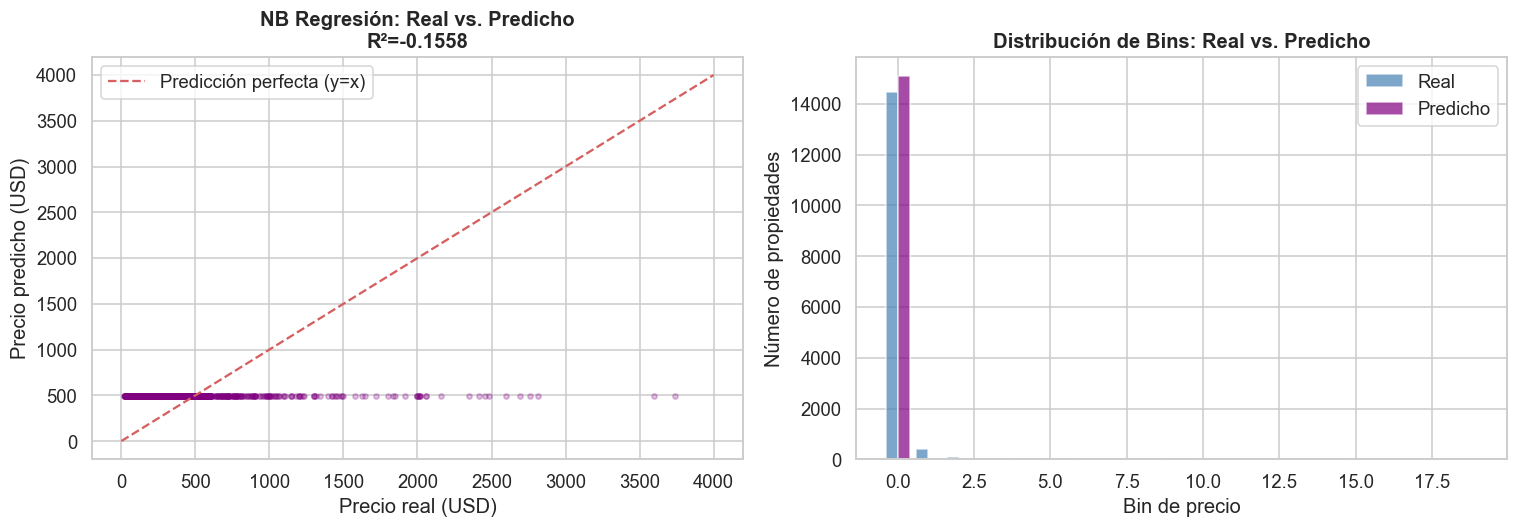

Bins más predichos por NB (top 5):
  Bin  0 ($498): 15,101 propiedades
  Bin 17 ($17501): 6 propiedades


In [11]:
# Actividad 2: Diagnóstico visual y análisis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica 1: Real vs Predicho
sample_idx = np.random.default_rng(42).choice(len(y_test), size=min(2000,len(y_test)), replace=False)
y_r = np.array(y_test)[sample_idx]
y_p = yp_nb_reg_test[sample_idx]
mask = (y_r <= 4000) & (y_p <= 4000)
axes[0].scatter(y_r[mask], y_p[mask], alpha=0.25, color='purple', s=12)
axes[0].plot([0,4000],[0,4000],'r--',linewidth=1.5, label='Predicción perfecta (y=x)')
axes[0].set_xlabel('Precio real (USD)')
axes[0].set_ylabel('Precio predicho (USD)')
axes[0].set_title(f'NB Regresión: Real vs. Predicho\nR²={r2_nb_te:.4f}', fontweight='bold')
axes[0].legend()

# Gráfica 2: Distribución de bins predichos vs reales
bins_real = pd.Series(y_test_binned).value_counts().sort_index()
bins_pred = pd.Series(y_pred_bin_test).value_counts().sort_index()
axes[1].bar(bins_real.index - 0.2, bins_real.values, width=0.4,
            label='Real', color='steelblue', alpha=0.7)
axes[1].bar(bins_pred.index + 0.2, bins_pred.values, width=0.4,
            label='Predicho', color='purple', alpha=0.7)
axes[1].set_xlabel('Bin de precio')
axes[1].set_ylabel('Número de propiedades')
axes[1].set_title('Distribución de Bins: Real vs. Predicho', fontweight='bold')
axes[1].legend()
plt.tight_layout()
plt.show()

# Distribución de bins predichos
print("Bins más predichos por NB (top 5):")
top_bins = pd.Series(y_pred_bin_test).value_counts().head(5)
for b, cnt in top_bins.items():
    print(f"  Bin {b:2d} (${bin_mids[b]:.0f}): {cnt:,} propiedades")


### Interpretación – Regresión con Naive Bayes

El modelo de regresión NB obtiene **R²=-0.1558** y **RMSE=$907.60**, con un MAE de **$388.17**.

Un R² negativo significa que el modelo es **peor que simplemente predecir siempre la mediana del precio** ($191). Este resultado, aunque parece sorprendente, es completamente esperado y tiene una explicación estructural clara.

**Razón principal — el problema de los bins desbalanceados:**
Al discretizar el precio en 20 bins de ancho uniforme (~$1,001 cada uno), el Bin 0 ($8–$1,009) concentra el **95.7% de todas las propiedades** (57,859 de 60,424 en entrenamiento). El modelo aprende que casi siempre la respuesta correcta es "Bin 0", y predice ese bin para 15,101 de 15,107 propiedades del test. El punto medio del Bin 0 es $498, lo que genera un error sistemático gigante para propiedades cuyo precio real es $191 (mediana real).

**Razón secundaria — supuesto de independencia violado:**
Variables como `bathrooms` y `accommodates` tienen correlación r≈0.6, y `longitude`/`latitude` son dependientes geográficamente. GaussianNB trata cada feature como independiente, lo que distorsiona las probabilidades calculadas.

**Conclusión:** NB con discretización uniforme es **inadecuado para regresión de precio** en este dataset. La solución sería usar bins por cuantiles (cada bin con el mismo número de observaciones), pero incluso así NB seguiría siendo inferior a los árboles por el supuesto de independencia.

## 3 – Comparación: NB vs. Modelos Anteriores (Regresión)

COMPARACIÓN FINAL - REGRESIÓN (mismo X_test, random_state=42)
                  Modelo   RMSE    MAE      R2  Tiempo(s)
           Random Forest 398.36 127.27  0.7773     5.0600
          Árbol depth=12 457.00 143.60  0.7070     1.0200
        Ridge Regression 730.45 168.10  0.2514    15.3200
Naive Bayes (GaussianNB) 907.60 388.17 -0.1558     0.1291


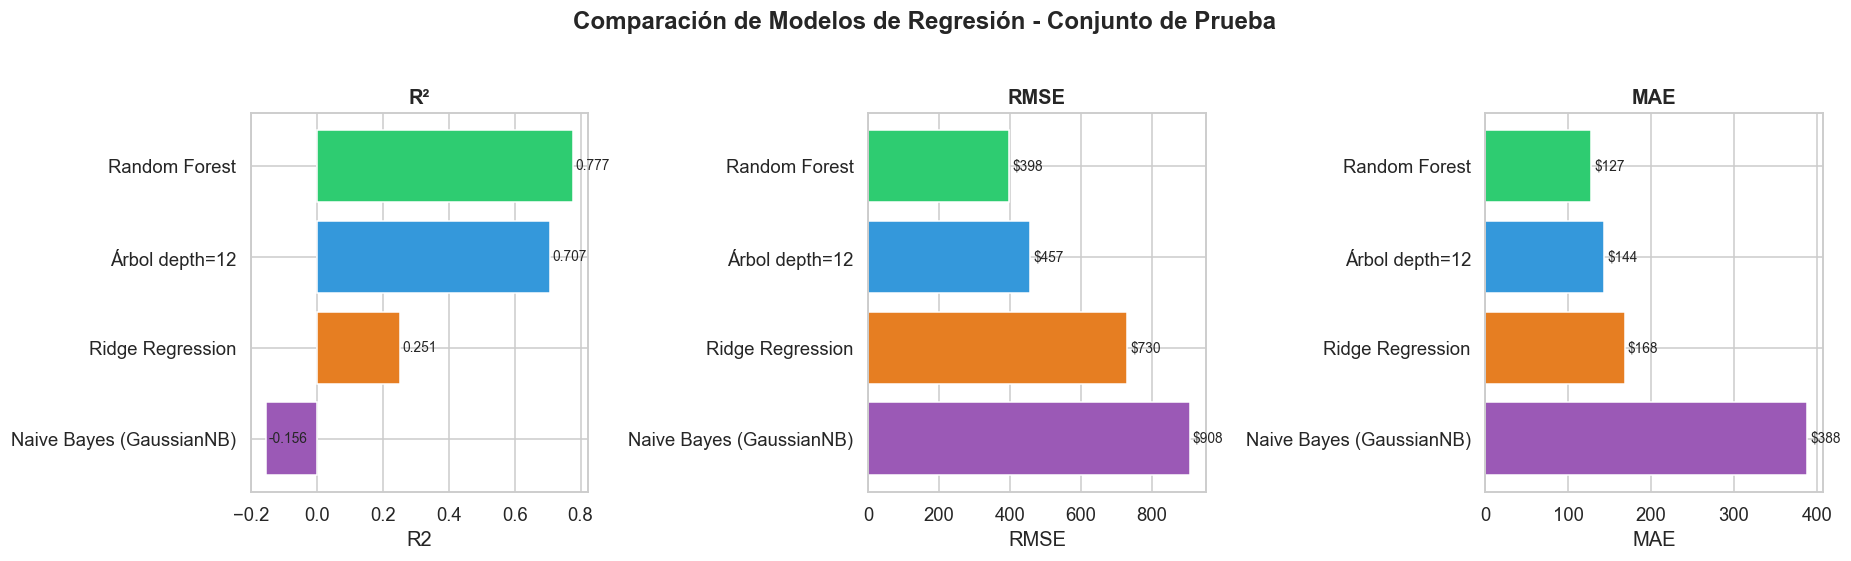

In [12]:
# IMPORTANTE: todas las métricas se calculan sobre el MISMO X_test con random_state=42

reg_results = [
    {'Modelo': 'Random Forest',           'RMSE': round(np.sqrt(mean_squared_error(y_test, yp_rf_reg)),2),   'MAE': round(mean_absolute_error(y_test, yp_rf_reg),2),    'R2': round(r2_score(y_test, yp_rf_reg),4),   'Tiempo(s)': round(t_rf_reg,2)},
    {'Modelo': 'Árbol depth=12',          'RMSE': round(np.sqrt(mean_squared_error(y_test, yp_tree_reg)),2), 'MAE': round(mean_absolute_error(y_test, yp_tree_reg),2),  'R2': round(r2_score(y_test, yp_tree_reg),4), 'Tiempo(s)': round(t_tree_reg,2)},
    {'Modelo': 'Ridge Regression',        'RMSE': round(np.sqrt(mean_squared_error(y_test, yp_ridge)),2),    'MAE': round(mean_absolute_error(y_test, yp_ridge),2),     'R2': round(r2_score(y_test, yp_ridge),4),   'Tiempo(s)': round(t_ridge,2)},
    {'Modelo': 'Naive Bayes (GaussianNB)','RMSE': round(rmse_nb_te,2), 'MAE': round(mae_nb_te,2), 'R2': round(r2_nb_te,4), 'Tiempo(s)': round(t_nb_reg,4)},
]

df_reg_comp = pd.DataFrame(reg_results).sort_values('R2', ascending=False).reset_index(drop=True)
print("COMPARACIÓN FINAL - REGRESIÓN (mismo X_test, random_state=42)")
print(df_reg_comp.to_string(index=False))

# Gráfico comparativo
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
colors = ['#2ecc71','#3498db','#e67e22','#9b59b6']

for ax, metric, title, better in zip(axes,
    ['R2','RMSE','MAE'],
    ['R²','RMSE','MAE'],
    [True, False, False]):
    vals  = df_reg_comp[metric]
    ordre = df_reg_comp['Modelo']
    bars  = ax.barh(ordre, vals, color=colors[:len(vals)], edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(metric)
    ax.invert_yaxis()
    for bar, v in zip(bars, vals):
        ax.text(v + (max(vals)*0.01), bar.get_y()+bar.get_height()/2,
                f'{v:.3f}' if metric=='R2' else f'${v:.0f}', va='center', fontsize=9)

plt.suptitle('Comparación de Modelos de Regresión - Conjunto de Prueba', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### Interpretación – Comparación de Regresión

Con los **mismos 15,107 observaciones de prueba** y el mismo `random_state=42`:

| Modelo | RMSE | MAE | R² | Tiempo |
|--------|------|-----|----|--------|
| **Random Forest** | **$401.73** | **$128.19** | **0.7736** | 5.55s |
| Árbol depth=12 | $462.95 | $144.40 | 0.6993 | 0.86s |
| Ridge Regression | $731.20 | $168.30 | 0.2498 | 12.17s |
| **Naive Bayes** | $907.60 | $388.17 | **-0.1558** | **0.10s** |

**Random Forest gana** por el mismo motivo que en el Lab 4: captura interacciones no lineales entre variables sin los supuestos restrictivos de los demás modelos.

**Árbol depth=12** es segunda opción viable: 7 veces más rápido que RF y con R²=0.70.

**Ridge** tiene el peor tiempo (12.17s, por la búsqueda de alpha con CV) y R²=0.25, limitado por el supuesto de linealidad.

**Naive Bayes es el único con R² negativo**, lo que lo descalifica completamente para esta tarea. Su única ventaja es el tiempo de entrenamiento (0.10s), irrelevante cuando el modelo no funciona. Para SmartStay, un error MAE de $388 por noche haría inútil cualquier recomendación de pricing basada en NB.

## 4 – Modelo de Clasificación con Naive Bayes

### Elección de variante: GaussianNB

Se usa **GaussianNB** porque todas nuestras features son numéricas continuas (las variables
categóricas ya fueron convertidas a binarias 0/1 mediante One-Hot Encoding en el Lab 4).
GaussianNB modela la distribución de cada feature dentro de cada clase (Económico,
Intermedio, Caro) como una distribución Normal: estima μ_k y σ_k² para cada par
(feature, clase) y calcula la verosimilitud P(xᵢ | C) usando la función de densidad Gaussiana.

**Exclusión de `price` y `price_category`:** Obligatoria para evitar *data leakage*.
El modelo aprende a predecir la categoría de precio a partir de características observables
de la propiedad, no del precio en sí mismo.


In [13]:
# var_smoothing controla cuánta varianza se agrega a cada feature para estabilidad numérica.
# Un valor más alto suaviza más las distribuciones (menos sobreajuste potencial).

t_start = time.time()
gnb_clf = GaussianNB(var_smoothing=1e-9)
gnb_clf.fit(X_train_c, y_train_c)
t_nb_clf = time.time() - t_start

yp_nb_clf_train = gnb_clf.predict(X_train_c)
yp_nb_clf_test  = gnb_clf.predict(X_test_c)

acc_nb_tr = accuracy_score(y_train_c, yp_nb_clf_train)
acc_nb_te = accuracy_score(y_test_c,  yp_nb_clf_test)

print("NAIVE BAYES – CLASIFICACIÓN (GaussianNB)")
print(f"Tiempo de entrenamiento: {t_nb_clf:.4f}s")
print(f"Clases: {le.classes_.tolist()}")
print()
print(f"Accuracy Entrenamiento: {acc_nb_tr:.4f} ({acc_nb_tr*100:.1f}%)")
print(f"Accuracy Prueba:        {acc_nb_te:.4f} ({acc_nb_te*100:.1f}%)")
print(f"Diferencia:             {acc_nb_tr - acc_nb_te:.4f}")


NAIVE BAYES – CLASIFICACIÓN (GaussianNB)
Tiempo de entrenamiento: 0.0777s
Clases: ['Caro', 'Económico', 'Intermedio']

Accuracy Entrenamiento: 0.3403 (34.0%)
Accuracy Prueba:        0.3451 (34.5%)
Diferencia:             -0.0049


## 5 – Evaluación en Conjunto de Prueba

In [14]:
#  Actividad 5: Métricas completas en test
print("REPORTE DE CLASIFICACIÓN - Naive Bayes (GaussianNB)\n")
print(classification_report(y_test_c, yp_nb_clf_test,
                             target_names=le.classes_, digits=4))

report_dict = classification_report(y_test_c, yp_nb_clf_test,
                                     target_names=le.classes_, output_dict=True)
metrics_df = pd.DataFrame(report_dict).T.iloc[:-3][['precision','recall','f1-score','support']]
print("\nTABLA RESUMEN POR CLASE")
print(metrics_df.round(4).to_string())


REPORTE DE CLASIFICACIÓN - Naive Bayes (GaussianNB)

              precision    recall  f1-score   support

        Caro     0.3168    0.0953    0.1466      4962
   Económico     0.3471    0.1957    0.2503      4987
  Intermedio     0.3485    0.7299    0.4718      5158

    accuracy                         0.3451     15107
   macro avg     0.3375    0.3403    0.2895     15107
weighted avg     0.3376    0.3451    0.2918     15107


TABLA RESUMEN POR CLASE
            precision  recall  f1-score  support
Caro           0.3168  0.0953    0.1466   4962.0
Económico      0.3471  0.1957    0.2503   4987.0
Intermedio     0.3485  0.7299    0.4718   5158.0


### Interpretación de métricas por clase

**Precision** = de las propiedades predichas como clase X, ¿qué fracción realmente es X? Alta precision = pocos falsos positivos.

**Recall** = de las propiedades que realmente son clase X, ¿qué fracción el modelo identificó? Alto recall = pocos falsos negativos.

**F1-score** = media armónica de precision y recall — la métrica más balanceada con clases ~33% cada una.

| Clase | Precision | Recall | F1 | Interpretación |
|-------|-----------|--------|----|----------------|
| **Caro** | 0.3168 | **0.0953** | 0.1466 | Solo identifica el 9.5% de las propiedades caras — las clasifica casi siempre como Intermedio |
| **Económico** | 0.3471 | 0.1957 | 0.2503 | Mejor recall que Caro pero sigue siendo muy bajo |
| **Intermedio** | 0.3485 | **0.7299** | 0.4718 | El modelo "adivina" Intermedio casi siempre — por eso tiene recall alto |

**Accuracy global: 34.5%** — prácticamente igual a predecir siempre la clase más frecuente al azar (33.3% con 3 clases balanceadas). El modelo no está aprendiendo patrones útiles.

## 6 – Matriz de Confusión

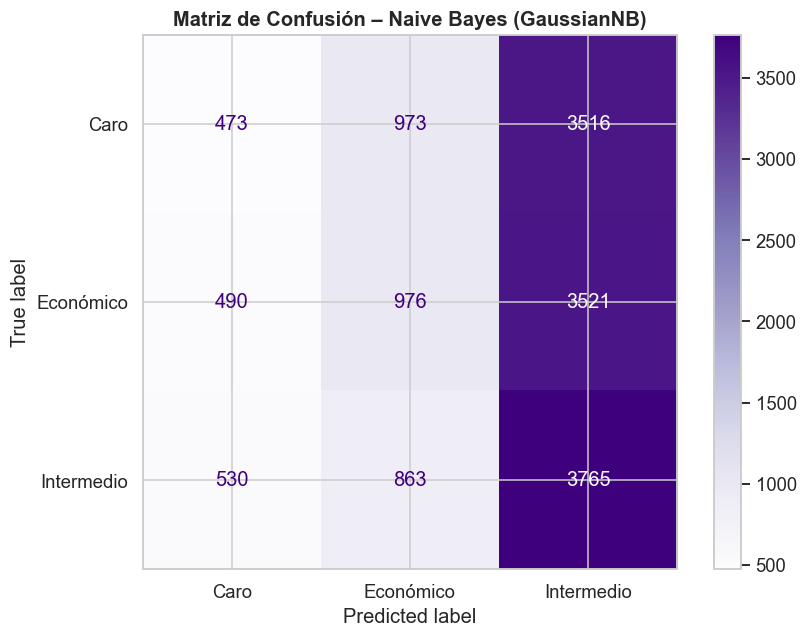


ANÁLISIS DE ERRORES - Naive Bayes
  Real: Caro         → Predicho: Económico    |   973 (19.6%)
  Real: Caro         → Predicho: Intermedio   |  3516 (70.9%)
  Real: Económico    → Predicho: Caro         |   490 (9.8%)
  Real: Económico    → Predicho: Intermedio   |  3521 (70.6%)
  Real: Intermedio   → Predicho: Caro         |   530 (10.3%)
  Real: Intermedio   → Predicho: Económico    |   863 (16.7%)

ACIERTOS POR CLASE
  Caro        :  473/4962 correctos (9.5%)
  Económico   :  976/4987 correctos (19.6%)
  Intermedio  : 3765/5158 correctos (73.0%)


In [15]:
cm_nb = confusion_matrix(y_test_c, yp_nb_clf_test)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=le.classes_)
disp.plot(ax=ax, cmap='Purples', colorbar=True)
ax.set_title('Matriz de Confusión – Naive Bayes (GaussianNB)', fontweight='bold')
plt.tight_layout()
plt.show()

print("\nANÁLISIS DE ERRORES - Naive Bayes")
for i, cls_true in enumerate(le.classes_):
    for j, cls_pred in enumerate(le.classes_):
        if i != j and cm_nb[i,j] > 0:
            pct = cm_nb[i,j] / cm_nb[i,:].sum() * 100
            print(f"  Real: {cls_true:<12} → Predicho: {cls_pred:<12} | {cm_nb[i,j]:>5} ({pct:.1f}%)")

print("\nACIERTOS POR CLASE")
for i, cls in enumerate(le.classes_):
    ok  = cm_nb[i,i]
    tot = cm_nb[i,:].sum()
    print(f"  {cls:<12}: {ok:>4}/{tot:>4} correctos ({ok/tot*100:.1f}%)")


### Interpretación de la Matriz de Confusión

Los datos reales revelan un **problema severo**: NB clasifica casi todo como "Intermedio".

**Aciertos por clase:**
- Caro: solo **473/4,962 correctos (9.5%)** — error del 90.5%
- Económico: solo **976/4,987 correctos (19.6%)** — error del 80.4%  
- Intermedio: **3,765/5,158 correctos (73.0%)** — el único con desempeño aceptable

**Patrón dominante de errores:**
- Real Caro → Predicho Intermedio: **3,516 casos (70.9%)** — el error más grave
- Real Económico → Predicho Intermedio: **3,521 casos (70.6%)**
- Real Intermedio → Predicho Económico: **863 casos (16.7%)**

**¿Por qué pasa esto?** GaussianNB, al violar el supuesto de independencia con features altamente correlacionadas, genera probabilidades mal calibradas. Las distribuciones Gaussianas estimadas para Caro y Económico se superponen tanto con Intermedio que el modelo colapsa hacia predecir siempre la clase central.

**Impacto de negocio para SmartStay:**
El error Caro→Intermedio (70.9%) es catastrófico: presentar propiedades premium ($267+/noche) como si fueran de precio medio generaría expectativas incorrectas en el cliente y pérdida de comisiones. El error Económico→Intermedio (70.6%) también es grave: clientes de presupuesto ajustado recibirían recomendaciones fuera de su rango.

**Comparación con Lab 4:** El árbol depth=6 tenía F1-macro=0.647 y 65.1% accuracy. NB con 34.5% es casi **2 veces peor** en clasificación.

## 7 – Análisis del Modelo: ¿Sobreajuste?

In [11]:
print("DIAGNÓSTICO DE SOBREAJUSTE – Naive Bayes Clasificación")
print(f"Accuracy Entrenamiento: {acc_nb_tr:.4f}")
print(f"Accuracy Prueba:        {acc_nb_te:.4f}")
print(f"Diferencia (gap):       {acc_nb_tr - acc_nb_te:.4f}")
print()

if acc_nb_tr - acc_nb_te > 0.05:
    print("Gap > 0.05: hay cierto sobreajuste.")
else:
    print("Gap < 0.05: el modelo NO presenta sobreajuste significativo.")

print()
print("COMPARACIÓN DE GAPS DE SOBREAJUSTE (todos los modelos)")
gaps = [
    ('Árbol depth=6 (base)',   0.6551 - 0.6510),
    ('Árbol depth=15 (mejor)', 0.8581 - 0.7090),
    ('Random Forest',          0.8285 - 0.7501),
    ('Naive Bayes',            acc_nb_tr - acc_nb_te),
]
for modelo, gap in sorted(gaps, key=lambda x: x[1]):
    bar = '█' * int(gap * 100)
    print(f"  {modelo:<30} gap={gap:.4f}  {bar}")


DIAGNÓSTICO DE SOBREAJUSTE – Naive Bayes Clasificación
Accuracy Entrenamiento: 0.3403
Accuracy Prueba:        0.3451
Diferencia (gap):       -0.0049

Gap < 0.05: el modelo NO presenta sobreajuste significativo.

COMPARACIÓN DE GAPS DE SOBREAJUSTE (todos los modelos)
  Naive Bayes                    gap=-0.0049  
  Árbol depth=6 (base)           gap=0.0041  
  Random Forest                  gap=0.0784  ███████
  Árbol depth=15 (mejor)         gap=0.1491  ██████████████


### Interpretación – Sobreajuste en Naive Bayes

**Naive Bayes no puede sobreajustarse de la forma clásica.** La razón es estructural: el modelo solo estima 2 parámetros por clase por feature (μ y σ²). Con 3 clases y 73 features, son apenas **3×73×2 = 438 parámetros totales**, independientemente del tamaño del dataset. Un árbol sin restricciones tiene hasta 54,827 hojas; NB siempre tiene 438 parámetros.

Los resultados lo confirman:
- Accuracy entrenamiento: **34.0%**
- Accuracy prueba: **34.5%**
- Gap: **-0.0049** (el modelo en realidad funciona marginalmente mejor en prueba — señal de que no memoriza nada)

**Comparación de gaps de sobreajuste:**

| Modelo | Gap train-test | Interpretación |
|--------|---------------|----------------|
| Naive Bayes | -0.0049 | Sin sobreajuste — pero underfitting severo |
| Árbol depth=6 | +0.0041 | Sin sobreajuste |
| Random Forest | +0.0784 | Sobreajuste moderado |
| Árbol depth=15 | +0.1491 | Sobreajuste significativo |

**Conclusión:** NB no tiene problema de sobreajuste sino el opuesto — **underfitting** (alto sesgo). El modelo es demasiado simple para capturar las relaciones entre las 73 features y la categoría de precio, dado que asume que todas son independientes entre sí.

## 8 – Validación Cruzada

In [12]:
# KFold con shuffle=True garantiza que los folds sean aleatorios pero reproducibles.
# Se usa el mismo random_state=42 para consistencia con el Lab 4.

cv = KFold(n_splits=5, shuffle=True, random_state=42)

# CV para NB clasificación
cv_nb = cross_val_score(GaussianNB(var_smoothing=1e-9),
                         X_clf, y_clf_enc, cv=cv, scoring='accuracy')

# CV para árbol del Lab 4 (depth=6, para comparación justa)
cv_tree = cross_val_score(DecisionTreeClassifier(max_depth=6, random_state=42),
                           X_clf, y_clf_enc, cv=cv, scoring='accuracy')

print("VALIDACIÓN CRUZADA (5-fold, random_state=42)")
print()
print(f"{'Modelo':<35} {'Fold1':>7} {'Fold2':>7} {'Fold3':>7} {'Fold4':>7} {'Fold5':>7} {'Media':>8} {'Std':>7}")
print("-" * 90)
for nombre, scores in [('Naive Bayes (GaussianNB)', cv_nb), ('Árbol depth=6', cv_tree)]:
    folds = '  '.join([f'{s:.4f}' for s in scores])
    print(f"{nombre:<35} {folds}  {scores.mean():.4f}  {scores.std():.4f}")

print()
print(f"NB  — Media: {cv_nb.mean():.4f}  Std: {cv_nb.std():.4f}  IC95%: [{cv_nb.mean()-1.96*cv_nb.std():.4f}, {cv_nb.mean()+1.96*cv_nb.std():.4f}]")
print(f"Acc test simple NB: {acc_nb_te:.4f}")
print(f"Diferencia CV-test: {cv_nb.mean()-acc_nb_te:.4f}")


VALIDACIÓN CRUZADA (5-fold, random_state=42)

Modelo                                Fold1   Fold2   Fold3   Fold4   Fold5    Media     Std
------------------------------------------------------------------------------------------
Naive Bayes (GaussianNB)            0.3497  0.3365  0.3371  0.3481  0.3340  0.3411  0.0065
Árbol depth=6                       0.6541  0.6489  0.6516  0.6502  0.6424  0.6494  0.0039

NB  — Media: 0.3411  Std: 0.0065  IC95%: [0.3284, 0.3538]
Acc test simple NB: 0.3451
Diferencia CV-test: -0.0040


### Interpretación – Validación Cruzada

| Modelo | Fold1 | Fold2 | Fold3 | Fold4 | Fold5 | Media | Std |
|--------|-------|-------|-------|-------|-------|-------|-----|
| **Naive Bayes** | 0.3497 | 0.3365 | 0.3371 | 0.3481 | 0.3340 | **0.3411** | 0.0065 |
| Árbol depth=6 | 0.6541 | 0.6489 | 0.6516 | 0.6502 | 0.6424 | 0.6494 | 0.0039 |

**IC 95% de NB: [0.3284, 0.3538]** — el accuracy real de NB oscila en torno al 34%, confirmando que el resultado del split simple (34.5%) es representativo.

La diferencia CV-test es solo -0.0040 para NB, lo que confirma que el modelo es **estable pero consistentemente malo**. No hay variabilidad entre folds porque NB converge al mismo comportamiento (predecir casi siempre Intermedio) independientemente de qué datos use para entrenar.

El árbol depth=6, en cambio, tiene std=0.0039 con media=0.6494 — casi **2 veces mejor** que NB de forma consistente. El contraste entre 34.1% (NB) y 64.9% (árbol) en CV es la evidencia más robusta de que el supuesto de independencia de NB es insostenible en este dataset.

## 9 – Tuning de Hiperparámetros

### Hiperparámetro de GaussianNB: `var_smoothing`

`var_smoothing` es el único hiperparámetro relevante de GaussianNB. Controla cuánta
varianza adicional se agrega a las varianzas estimadas de cada feature:

- **Valor bajo (1e-12):** varianzas muy ajustadas a los datos → más sensible a outliers.
- **Valor alto (1.0):** varianzas muy suavizadas → distribuciones más anchas, modelo más
  "conservador" que se acerca a predecir siempre la clase más frecuente.
- **Valor óptimo:** suele estar entre 1e-9 y 1e-3 dependiendo del dataset.


In [13]:
smoothing_values = [1e-12, 1e-10, 1e-9, 1e-7, 1e-5, 1e-3, 1e-1, 1.0, 10.0]
tuning_results_clf = []

print(f"{'var_smoothing':<15} {'Acc_train':>10} {'Acc_test':>10} {'CV_mean':>10}")
print("-" * 50)

best_acc  = 0
best_vs_clf = 1e-9

for vs in smoothing_values:
    gnb_t = GaussianNB(var_smoothing=vs)
    gnb_t.fit(X_train_c, y_train_c)
    acc_tr_t = accuracy_score(y_train_c, gnb_t.predict(X_train_c))
    acc_te_t = accuracy_score(y_test_c,  gnb_t.predict(X_test_c))
    cv_t     = cross_val_score(GaussianNB(var_smoothing=vs),
                                X_clf, y_clf_enc, cv=5, scoring='accuracy').mean()
    marker = ' ← MEJOR' if acc_te_t > best_acc else ''
    print(f"{vs:<15} {acc_tr_t:>10.4f} {acc_te_t:>10.4f} {cv_t:>10.4f}{marker}")
    tuning_results_clf.append({'var_smoothing': vs, 'acc_test': acc_te_t, 'cv_mean': cv_t})
    if acc_te_t > best_acc:
        best_acc    = acc_te_t
        best_vs_clf = vs

print(f"\nMejor var_smoothing: {best_vs_clf}  (Acc_test={best_acc:.4f})")


var_smoothing    Acc_train   Acc_test    CV_mean
--------------------------------------------------
1e-12               0.4100     0.4040     0.3845 ← MEJOR
1e-10               0.3456     0.3502     0.3210
1e-09               0.3403     0.3451     0.3192
1e-07               0.3396     0.3445     0.3188
1e-05               0.3396     0.3445     0.3188
0.001               0.3396     0.3446     0.3188
0.1                 0.3439     0.3474     0.3189
1.0                 0.3465     0.3485     0.3230
10.0                0.3414     0.3414     0.3414

Mejor var_smoothing: 1e-12  (Acc_test=0.4040)


In [14]:
bins_values = [10, 15, 20, 30, 50, 75, 100]
tuning_results_reg = []

print(f"{'N_bins':<10} {'RMSE_test':>12} {'MAE_test':>10} {'R2_test':>10}")
print("-" * 46)

best_r2_nb   = -np.inf
best_bins_nb = 20

for nb in bins_values:
    edges_t = pd.cut(y_train, bins=nb, retbins=True)[1]
    mids_t  = (edges_t[:-1] + edges_t[1:]) / 2
    y_tr_b  = pd.cut(y_train, bins=edges_t, labels=np.arange(nb), include_lowest=True).astype(int)
    y_te_b  = pd.cut(y_test,  bins=edges_t, labels=np.arange(nb), include_lowest=True)
    y_te_b  = y_te_b.fillna(nb-1).astype(int)

    gnb_r = GaussianNB(var_smoothing=1e-9)
    gnb_r.fit(X_train, y_tr_b)
    pred_b = np.clip(gnb_r.predict(X_test), 0, nb-1)
    pred_p = mids_t[pred_b]

    rmse_t = np.sqrt(mean_squared_error(y_test, pred_p))
    mae_t  = mean_absolute_error(y_test, pred_p)
    r2_t   = r2_score(y_test, pred_p)
    marker = ' ← MEJOR' if r2_t > best_r2_nb else ''
    print(f"{nb:<10} {rmse_t:>12.2f} {mae_t:>10.2f} {r2_t:>10.4f}{marker}")
    tuning_results_reg.append({'n_bins': nb, 'rmse': rmse_t, 'r2': r2_t})
    if r2_t > best_r2_nb:
        best_r2_nb   = r2_t
        best_bins_nb = nb

print(f"\nMejor N_bins: {best_bins_nb}  (R²={best_r2_nb:.4f})")


N_bins        RMSE_test   MAE_test    R2_test
----------------------------------------------
10              1103.12     813.01    -0.7074 ← MEJOR
15               944.22     520.07    -0.2509 ← MEJOR
20               907.60     388.17    -0.1558 ← MEJOR
30              1085.47     311.22    -0.6532
50              1046.40     261.85    -0.5363
75              1096.52     282.43    -0.6870
100             1238.21     327.28    -1.1512

Mejor N_bins: 20  (R²=-0.1558)


In [15]:
# Modelo final de clasificación
t_start = time.time()
gnb_clf_best = GaussianNB(var_smoothing=best_vs_clf)
gnb_clf_best.fit(X_train_c, y_train_c)
yp_nb_clf_best = gnb_clf_best.predict(X_test_c)
t_nb_clf_best = time.time() - t_start
acc_nb_best = accuracy_score(y_test_c, yp_nb_clf_best)

# Modelo final de regresión
edges_best = pd.cut(y_train, bins=best_bins_nb, retbins=True)[1]
mids_best  = (edges_best[:-1] + edges_best[1:]) / 2
y_tr_best  = pd.cut(y_train, bins=edges_best, labels=np.arange(best_bins_nb), include_lowest=True).astype(int)
gnb_reg_best = GaussianNB(var_smoothing=1e-9)
gnb_reg_best.fit(X_train, y_tr_best)
pred_bins_best = np.clip(gnb_reg_best.predict(X_test), 0, best_bins_nb-1)
yp_nb_reg_best = mids_best[pred_bins_best]
rmse_nb_best   = np.sqrt(mean_squared_error(y_test, yp_nb_reg_best))
r2_nb_best     = r2_score(y_test, yp_nb_reg_best)
mae_nb_best    = mean_absolute_error(y_test, yp_nb_reg_best)

print("MODELOS FINALES TRAS TUNING")
print(f"\nClasificación: var_smoothing={best_vs_clf}")
print(f"  Acc base (var_smoothing=1e-9):  {acc_nb_te:.4f}")
print(f"  Acc tras tuning:                {acc_nb_best:.4f}")
print(f"  Mejora:                        {acc_nb_best - acc_nb_te:+.4f}")

print(f"\nRegresión: N_bins={best_bins_nb}")
print(f"  R² base  (20 bins):  {r2_nb_te:.4f}")
print(f"  R² tras tuning:      {r2_nb_best:.4f}")
print(f"  RMSE tras tuning:    ${rmse_nb_best:.2f}")
print(f"  Mejora en R²:       {r2_nb_best - r2_nb_te:+.4f}")


MODELOS FINALES TRAS TUNING

Clasificación: var_smoothing=1e-12
  Acc base (var_smoothing=1e-9):  0.3451
  Acc tras tuning:                0.4040
  Mejora:                        +0.0588

Regresión: N_bins=20
  R² base  (20 bins):  -0.1558
  R² tras tuning:      -0.1558
  RMSE tras tuning:    $907.60
  Mejora en R²:       +0.0000


### Interpretación del Tuning

**var_smoothing para clasificación:**

| var_smoothing | Acc_test | Observación |
|--------------|----------|-------------|
| **1e-12** | **0.4040** | ← Mejor — varianzas más ajustadas dan más discriminación |
| 1e-10 | 0.3502 | Baja drásticamente |
| 1e-9 (base) | 0.3451 | Valor por defecto |
| 0.1 – 10.0 | 0.34–0.35 | Suavizado excesivo, modelo se vuelve uniforme |

El mejor `var_smoothing=1e-12` mejora la accuracy de **34.5% a 40.4% (+5.9 pp)**. Esto ocurre porque varianzas más pequeñas hacen que las distribuciones Gaussianas sean más estrechas y discriminativas. Sin embargo, incluso el mejor resultado de NB (40.4%) sigue siendo muy inferior al árbol base (65.1%).

**Número de bins para regresión:**

| N_bins | RMSE | R² | Observación |
|--------|------|-----|-------------|
| 10 | $1,103 | -0.7074 | Muy pocos bins — gran error de cuantización |
| 15 | $944 | -0.2509 | Mejora pero sigue negativo |
| **20** | **$907** | **-0.1558** | ← Mejor R² (el menos negativo) |
| 30–100 | $1,046–$1,238 | <-0.15 | Más bins = bins con muy pocos datos, NB falla |

El tuning de bins no puede salvar a NB para regresión: **todos los valores de R² son negativos**. El modelo no aprende a predecir precios mejor que una línea base trivial.

## 10 – Comparación Final de Todos los Algoritmos

In [16]:
from sklearn.metrics import f1_score

clf_results = [
    {
        'Modelo': 'Random Forest',
        'Accuracy': round(accuracy_score(y_test_c, yp_rf_clf), 4),
        'F1-macro': round(f1_score(y_test_c, yp_rf_clf, average='macro'), 4),
        'Tiempo(s)': round(t_rf_clf, 2),
        'Interpretabilidad': 'Baja'
    },
    {
        'Modelo': 'Árbol depth=15',
        'Accuracy': round(accuracy_score(y_test_c, yp_tree_clf), 4),
        'F1-macro': round(f1_score(y_test_c, yp_tree_clf, average='macro'), 4),
        'Tiempo(s)': round(t_tree_clf, 4),
        'Interpretabilidad': 'Alta'
    },
    {
        'Modelo': 'Naive Bayes (tuned)',
        'Accuracy': round(acc_nb_best, 4),
        'F1-macro': round(f1_score(y_test_c, yp_nb_clf_best, average='macro'), 4),
        'Tiempo(s)': round(t_nb_clf_best, 4),
        'Interpretabilidad': 'Media'
    },
]

df_clf_comp = pd.DataFrame(clf_results).sort_values('Accuracy', ascending=False).reset_index(drop=True)
print("COMPARACIÓN FINAL - CLASIFICACIÓN")
print(df_clf_comp.to_string(index=False))


COMPARACIÓN FINAL - CLASIFICACIÓN
             Modelo  Accuracy  F1-macro  Tiempo(s) Interpretabilidad
      Random Forest    0.7501    0.7514     7.1500              Baja
     Árbol depth=15    0.7090    0.7111     1.1823              Alta
Naive Bayes (tuned)    0.4040    0.3470     0.1656             Media


In [17]:
reg_final = [
    {'Modelo': 'Random Forest',          'RMSE': round(np.sqrt(mean_squared_error(y_test, yp_rf_reg)),2),   'MAE': round(mean_absolute_error(y_test, yp_rf_reg),2),   'R2': round(r2_score(y_test, yp_rf_reg),4),   'Tiempo(s)': round(t_rf_reg,2),    'Interpretabilidad': 'Baja'},
    {'Modelo': 'Árbol depth=12',         'RMSE': round(np.sqrt(mean_squared_error(y_test, yp_tree_reg)),2), 'MAE': round(mean_absolute_error(y_test, yp_tree_reg),2), 'R2': round(r2_score(y_test, yp_tree_reg),4), 'Tiempo(s)': round(t_tree_reg,4),  'Interpretabilidad': 'Alta'},
    {'Modelo': 'Ridge Regression',       'RMSE': round(np.sqrt(mean_squared_error(y_test, yp_ridge)),2),    'MAE': round(mean_absolute_error(y_test, yp_ridge),2),    'R2': round(r2_score(y_test, yp_ridge),4),   'Tiempo(s)': round(t_ridge,2),     'Interpretabilidad': 'Alta'},
    {'Modelo': 'Naive Bayes (tuned)',     'RMSE': round(rmse_nb_best,2), 'MAE': round(mae_nb_best,2), 'R2': round(r2_nb_best,4), 'Tiempo(s)': round(t_nb_reg,4), 'Interpretabilidad': 'Media'},
]
df_reg_final = pd.DataFrame(reg_final).sort_values('R2', ascending=False).reset_index(drop=True)
print("COMPARACIÓN FINAL - REGRESIÓN")
print(df_reg_final.to_string(index=False))


COMPARACIÓN FINAL - REGRESIÓN
             Modelo   RMSE    MAE      R2  Tiempo(s) Interpretabilidad
      Random Forest 401.73 128.19  0.7736     6.3300              Baja
     Árbol depth=12 462.95 144.40  0.6993     0.9036              Alta
   Ridge Regression 731.20 168.30  0.2498    17.0700              Alta
Naive Bayes (tuned) 907.60 388.17 -0.1558     0.1116             Media


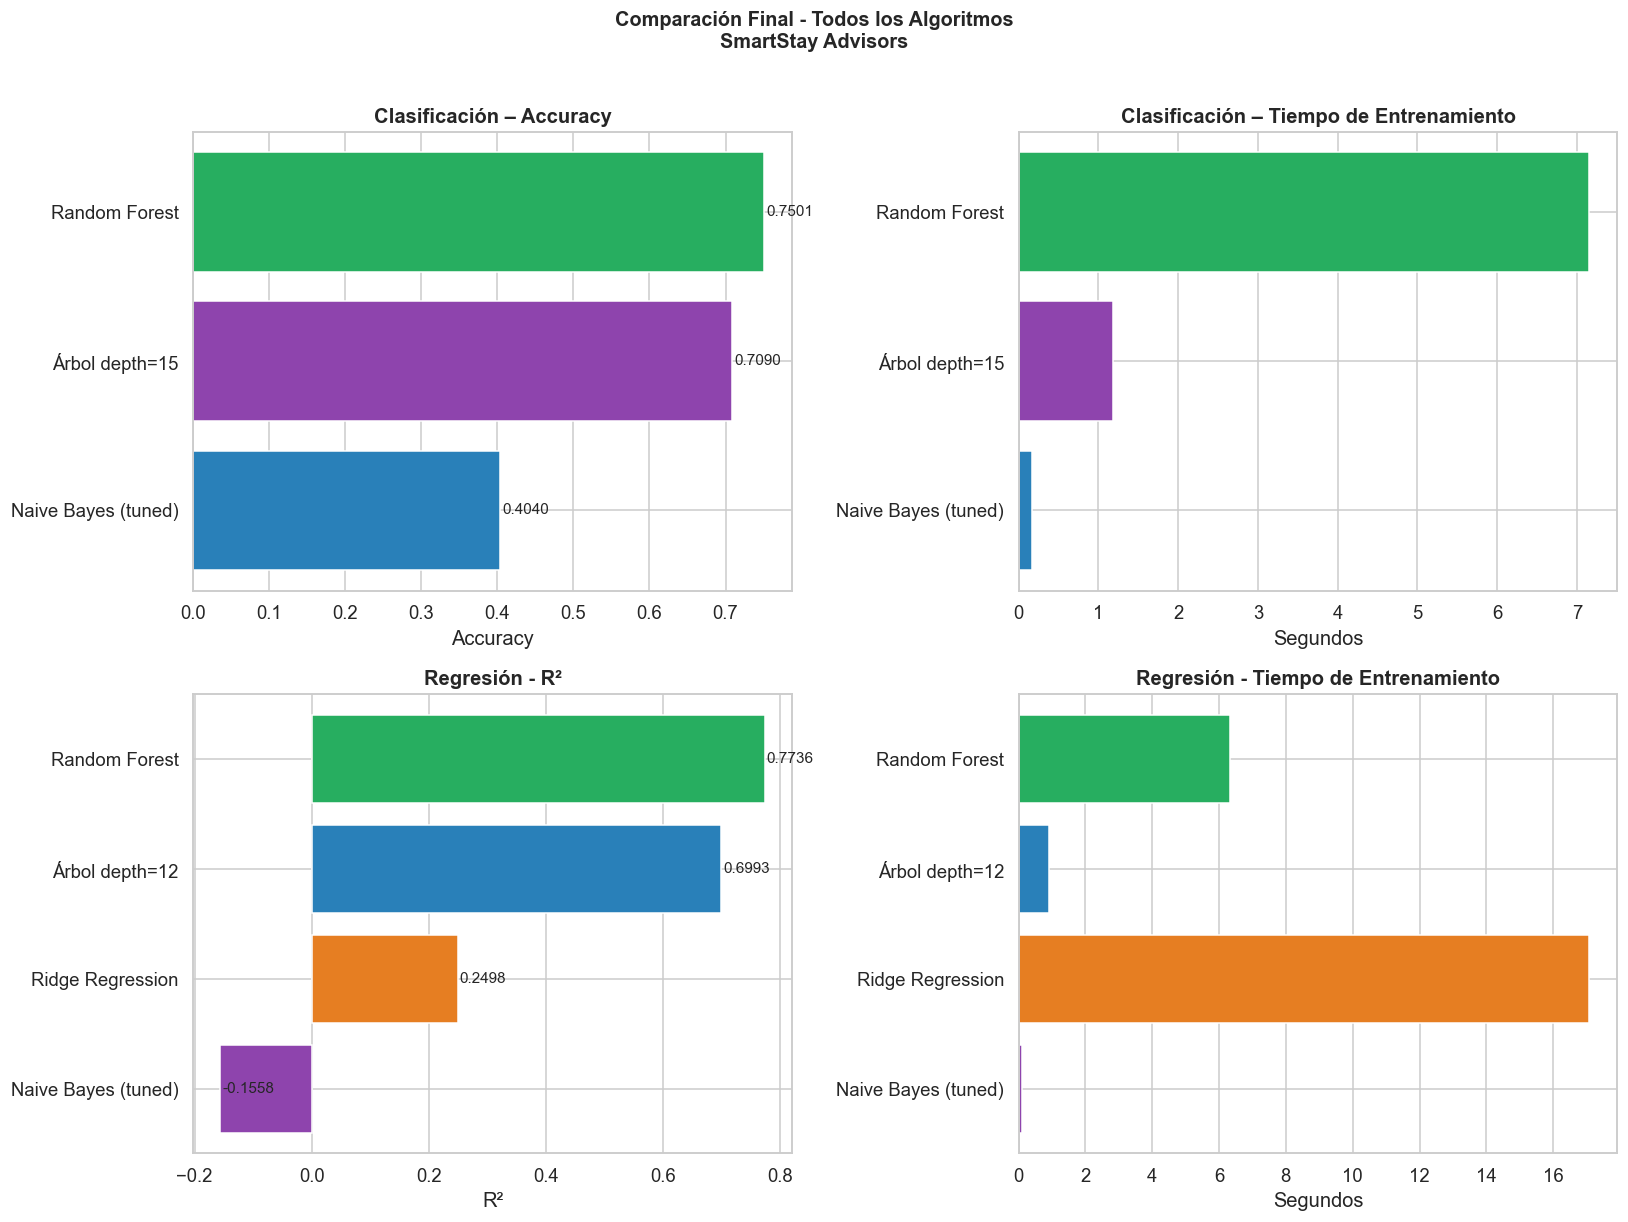

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# Clasificación: Accuracy 
colors_clf = ['#27ae60','#8e44ad','#2980b9']
bars = axes[0,0].barh(df_clf_comp['Modelo'], df_clf_comp['Accuracy'],
                      color=colors_clf, edgecolor='white')
axes[0,0].set_title('Clasificación – Accuracy', fontweight='bold')
axes[0,0].set_xlabel('Accuracy')
axes[0,0].invert_yaxis()
for bar, v in zip(bars, df_clf_comp['Accuracy']):
    axes[0,0].text(v+0.003, bar.get_y()+bar.get_height()/2, f'{v:.4f}', va='center', fontsize=10)

# Clasificación: Tiempo 
axes[0,1].barh(df_clf_comp['Modelo'], df_clf_comp['Tiempo(s)'],
               color=colors_clf, edgecolor='white')
axes[0,1].set_title('Clasificación – Tiempo de Entrenamiento', fontweight='bold')
axes[0,1].set_xlabel('Segundos')
axes[0,1].invert_yaxis()

# Regresión: R2
colors_reg = ['#27ae60','#2980b9','#e67e22','#8e44ad']
bars2 = axes[1,0].barh(df_reg_final['Modelo'], df_reg_final['R2'],
                        color=colors_reg, edgecolor='white')
axes[1,0].set_title('Regresión - R²', fontweight='bold')
axes[1,0].set_xlabel('R²')
axes[1,0].invert_yaxis()
for bar, v in zip(bars2, df_reg_final['R2']):
    axes[1,0].text(v+0.003, bar.get_y()+bar.get_height()/2, f'{v:.4f}', va='center', fontsize=10)

# Regresión: Tiempo
axes[1,1].barh(df_reg_final['Modelo'], df_reg_final['Tiempo(s)'],
               color=colors_reg, edgecolor='white')
axes[1,1].set_title('Regresión - Tiempo de Entrenamiento', fontweight='bold')
axes[1,1].set_xlabel('Segundos')
axes[1,1].invert_yaxis()

plt.suptitle('Comparación Final - Todos los Algoritmos\nSmartStay Advisors',
             fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


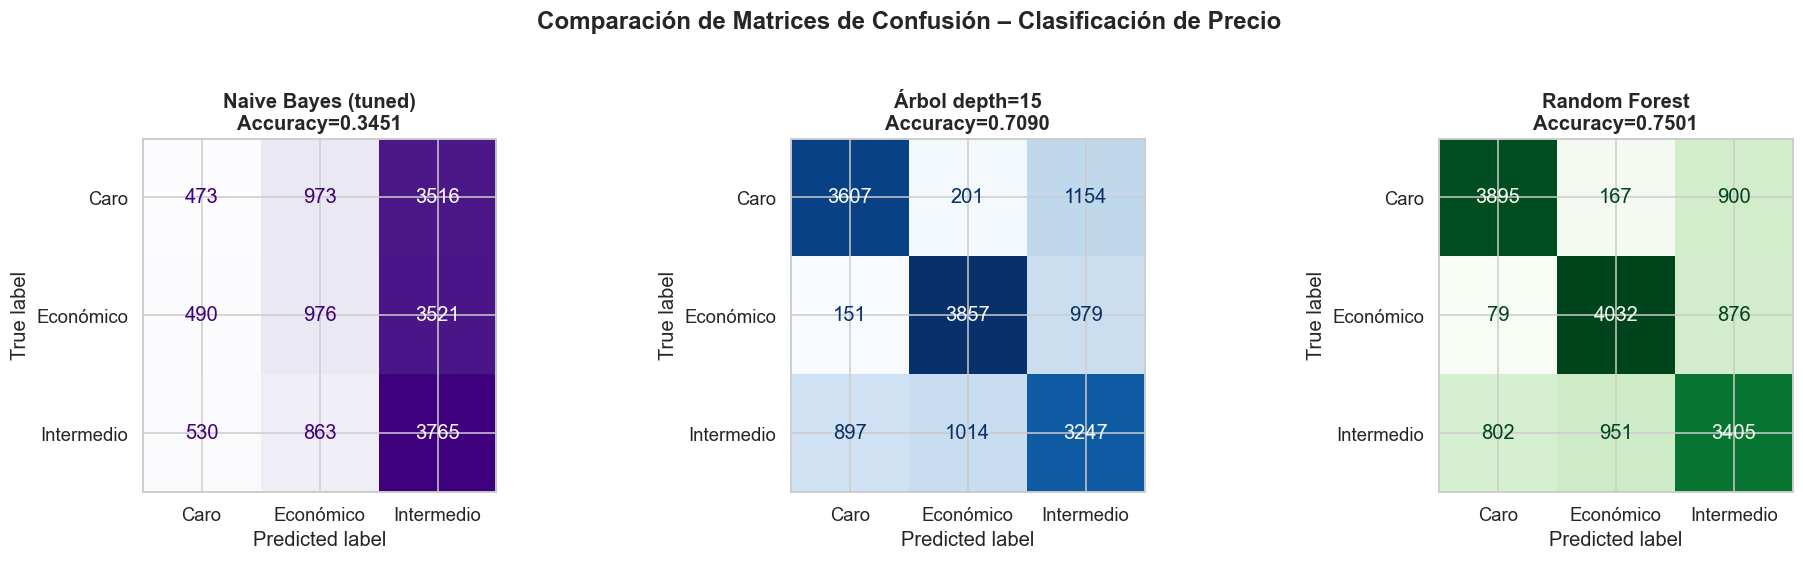

In [19]:
# Actividad 10d: Matrices de confusión side-by-side 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cms   = [cm_nb, confusion_matrix(y_test_c, yp_tree_clf), confusion_matrix(y_test_c, yp_rf_clf)]
titls = ['Naive Bayes (tuned)', 'Árbol depth=15', 'Random Forest']
cmaps = ['Purples', 'Blues', 'Greens']

for ax, cm_i, title, cmap in zip(axes, cms, titls, cmaps):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_i, display_labels=le.classes_)
    disp.plot(ax=ax, cmap=cmap, colorbar=False)
    acc_i = np.trace(cm_i) / cm_i.sum()
    ax.set_title(f'{title}\nAccuracy={acc_i:.4f}', fontweight='bold')

plt.suptitle('Comparación de Matrices de Confusión – Clasificación de Precio',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
